In [2]:
# =========================================================
# Simple Linear Regression in AWS SageMaker Studio
# Target relationship: y = 2x + 1
# =========================================================

# Run this in a SageMaker Studio notebook using the
# "Data Science" or "Python 3" kernel image.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Generate synthetic data based on y = 2x + 1 (+ noise)
# ---------------------------------------------------------
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)  # feature: x
y = 2 * X + 1
#noise = np.random.normal(0, 1, X.shape)             # small random noise
#y = 2 * X + 1 + noise                               # target: y = 2x + 1 + noise

In [3]:
# ---------------------------------------------------------
# 2. Split into train/test sets
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# ---------------------------------------------------------
# 3. Train the Linear Regression model
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Learned coefficient (slope):     {model.coef_[0][0]:.4f}  (expected ~2)")
print(f"Learned intercept:               {model.intercept_[0]:.4f}  (expected ~1)")

Learned coefficient (slope):     2.0000  (expected ~2)
Learned intercept:               1.0000  (expected ~1)


In [5]:
# ---------------------------------------------------------
# 4. Evaluate the model
# ---------------------------------------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score:          {r2:.4f}")

Mean Squared Error: 0.0000
R^2 Score:          1.0000


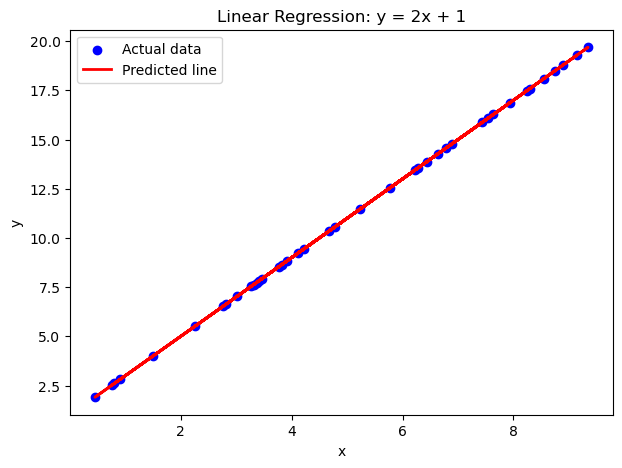

In [6]:
# ---------------------------------------------------------
# 5. Visualize the fit
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color="blue", label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted line")
plt.title("Linear Regression: y = 2x + 1")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("linear_regression_fit.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ---------------------------------------------------------
# 6. (Optional) Save the model for later use / deployment
# ---------------------------------------------------------
import joblib
joblib.dump(model, "linear_model.joblib")
print("Model saved as linear_model.joblib")

Model saved as linear_model.joblib


In [8]:
# ---------------------------------------------------------
# 7. (Optional) Predict on new data
# ---------------------------------------------------------
new_x = np.array([[15], [20]])
predictions = model.predict(new_x)
print("Predictions for x=15, x=20:", predictions.ravel())

Predictions for x=15, x=20: [31. 41.]
